In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

import pandas as pd
import numpy as np
sales_data = pd.read_csv('retail_sales_dataset.csv')
print(sales_data.head())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [41]:
print(sales_data.info())
print(sales_data.describe())
print(sales_data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    

In [42]:
sales_data['Gender'].value_counts()


,count
Gender,
Female,510
Male,490


In [43]:
sales_data['Product Category'].value_counts()

,count
Product Category,
Clothing,351
Electronics,342
Beauty,307


In [44]:
sales_data['Date'] = pd.to_datetime(sales_data['Date'])

<Axes: title={'center': 'Daily Sales Trends'}, xlabel='Date'>

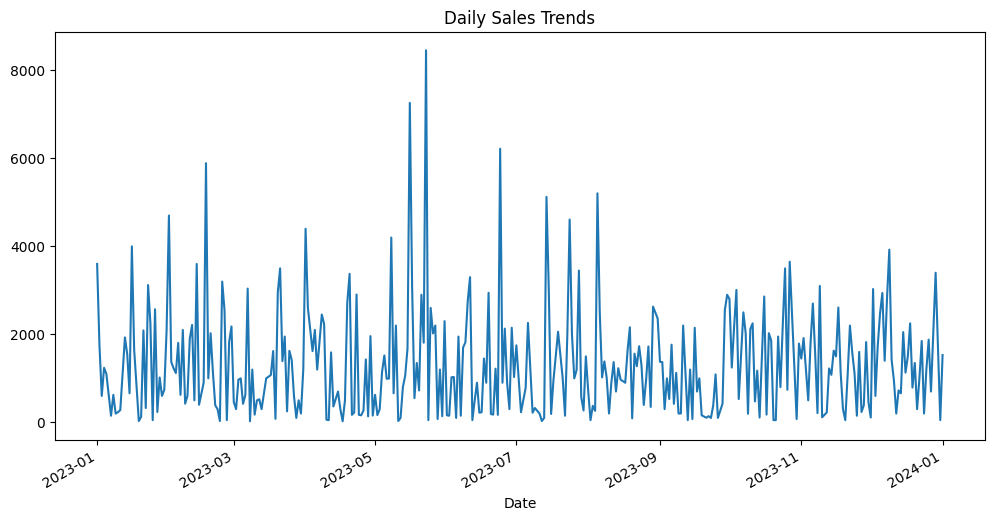

In [45]:
daily_sales = sales_data.groupby('Date')['Total Amount'].sum()
daily_sales.plot(figsize=(12, 6), title='Daily Sales Trends')

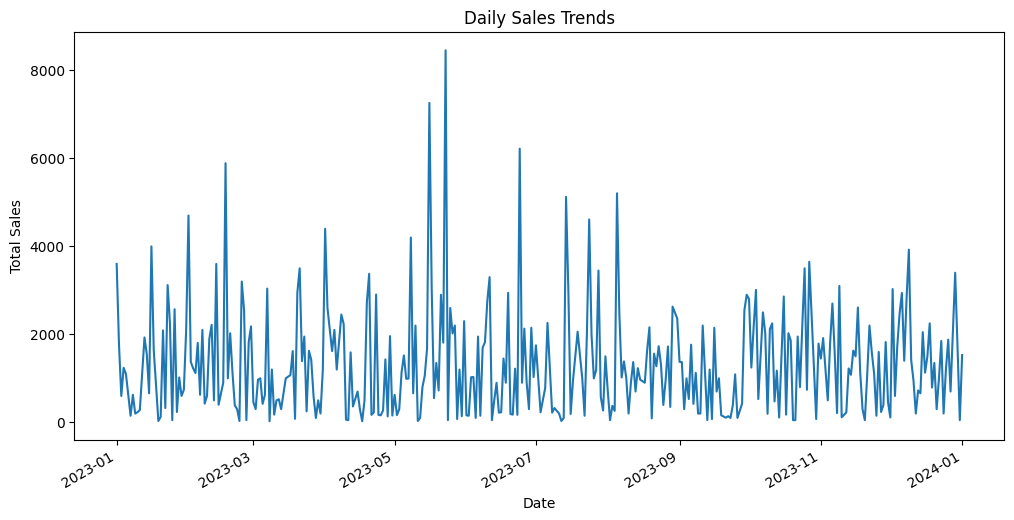

In [46]:
import matplotlib.pyplot as plt
daily_sales.plot(figsize=(12, 6), title='Daily Sales Trends')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

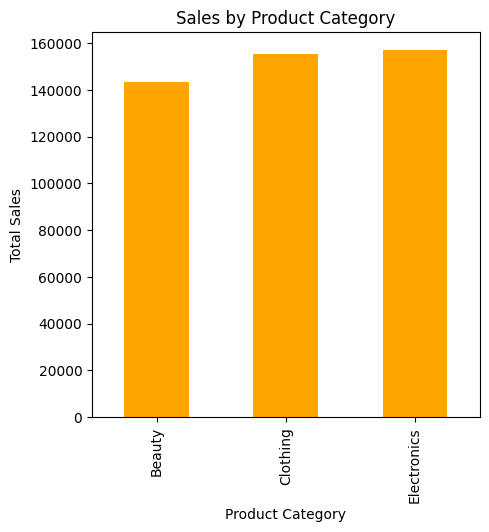

In [47]:
category_sales = sales_data.groupby('Product Category')['Total Amount'].sum()
category_sales.sort_values().plot(kind='bar', figsize=(5, 5), title='Sales by Product Category', color='orange')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.show()

<Axes: title={'center': 'Gender Distribution'}, ylabel='count'>

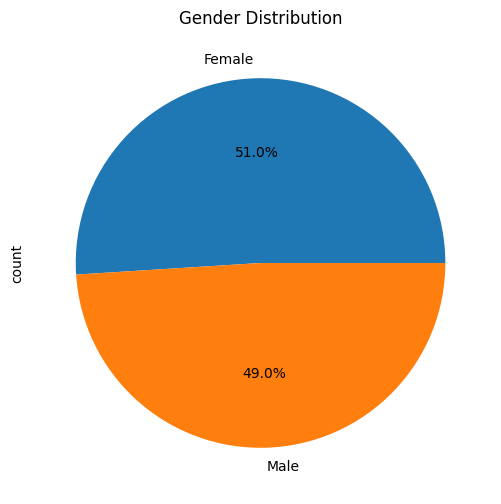

In [48]:

sales_data['Gender'].value_counts().plot(kind='pie',autopct='%1.1f%%',figsize=(6, 6), title='Gender Distribution')

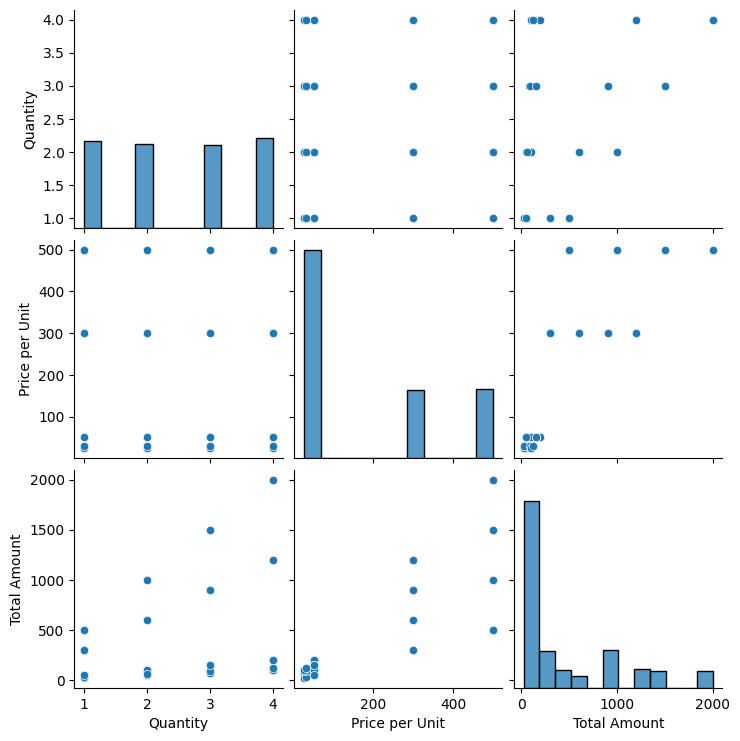

In [49]:
import seaborn as sns
# Pairplot to visualize relationships
sns.pairplot(sales_data[['Quantity', 'Price per Unit', 'Total Amount']])
plt.show()

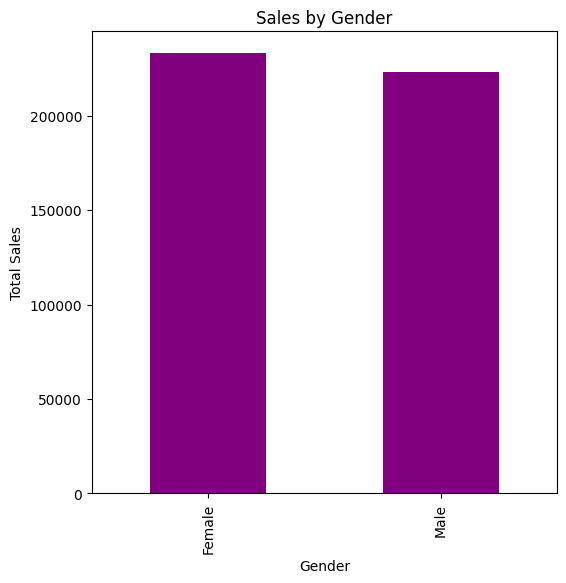

In [50]:
gender_sales = sales_data.groupby('Gender')['Total Amount'].sum()
gender_sales.plot(kind='bar', figsize=(6, 6), title='Sales by Gender', color='purple')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.show()

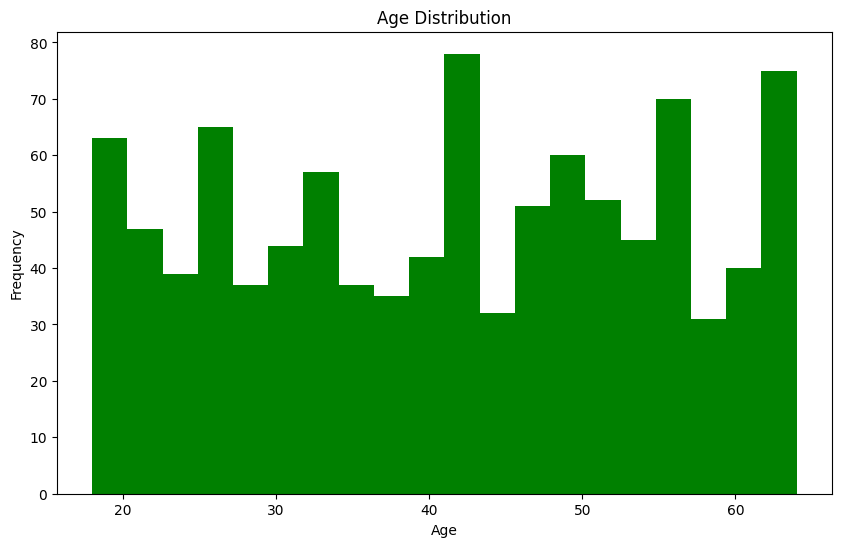

In [51]:
sales_data['Age'].plot(kind='hist', bins=20, figsize=(10, 6), title='Age Distribution', color='green')
plt.xlabel('Age')
plt.show()



In [52]:
daily_sales = sales_data.groupby('Date')['Total Amount'].sum()

<Axes: title={'center': 'total amounts distribution'}>

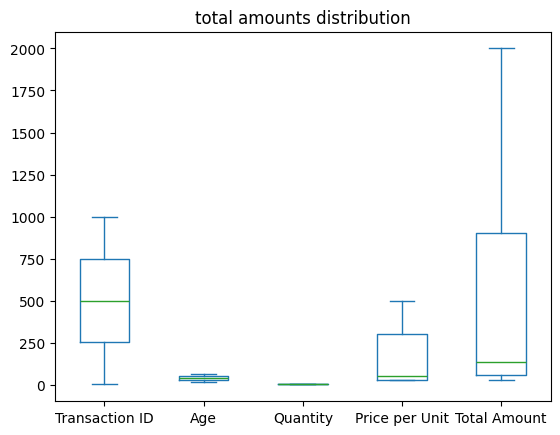

In [53]:
sales_data.plot(kind='box', title = 'total amounts distribution')

In [54]:
from scipy.stats import zscore

sales_data['Z-score'] = zscore(sales_data['Total Amount'])

outliers = sales_data[abs(sales_data['Z-score'])>2]

print(outliers)

     Transaction ID       Date Customer ID  Gender  Age Product Category  \
14               15 2023-01-16     CUST015  Female   42      Electronics   
64               65 2023-12-05     CUST065    Male   51      Electronics   
71               72 2023-05-23     CUST072  Female   20      Electronics   
73               74 2023-11-22     CUST074  Female   18           Beauty   
88               89 2023-10-01     CUST089  Female   55      Electronics   
92               93 2023-07-14     CUST093  Female   35           Beauty   
108             109 2023-10-18     CUST109  Female   34      Electronics   
117             118 2023-05-16     CUST118  Female   30      Electronics   
123             124 2023-10-27     CUST124    Male   33         Clothing   
138             139 2023-12-15     CUST139    Male   36           Beauty   
151             152 2023-02-28     CUST152    Male   43      Electronics   
154             155 2023-05-17     CUST155    Male   31      Electronics   
156         

In [55]:
Q1 = sales_data['Total Amount'].quantile(0.25)
Q3 = sales_data['Total Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound,upper_bound)
print(Q1,Q3)

-1200.0 2160.0
60.0 900.0


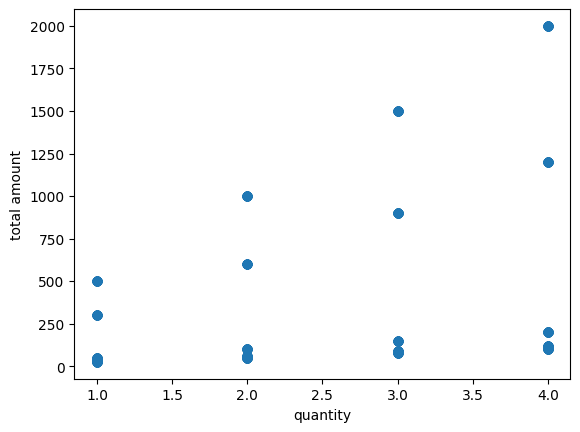

In [56]:
import matplotlib.pyplot as plt

plt.scatter(sales_data['Quantity'],sales_data['Total Amount'])
plt.xlabel('quantity')
plt.ylabel('total amount')
plt.show()

<Axes: title={'center': 'Total Amount Distribution'}, ylabel='Frequency'>

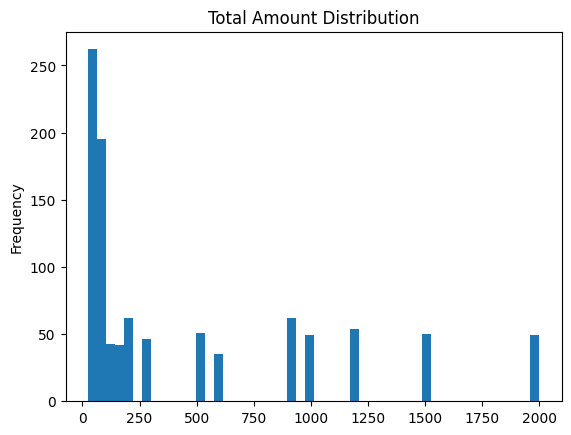

In [57]:
sales_data['Total Amount'].plot(kind='hist', bins=50, title='Total Amount Distribution')


In [58]:
sales_data['Year'] = sales_data['Date'].dt.year
sales_data['Month'] = sales_data['Date'].dt.month
sales_data['Day'] = sales_data['Date'].dt.day
sales_data['DayOfWeek'] = sales_data['Date'].dt.dayofweek
sales_data['isWeekend'] = sales_data['DayOfWeek'].apply(lambda x:1 if x>=5 else 0 )


In [59]:
# age calculation
bins = [0,20,40,60,80]
labels = ['<20','20-40','40-60','>60']
sales_data['Age Group'] = pd.cut(sales_data['Age'],bins=bins,labels=labels)


In [60]:
# now gender
sales_data['Gender Encoded'] = sales_data['Gender'].map({'Male':0 , 'Female' : 1 })


In [61]:
avg_price = sales_data.groupby('Product Category')['Price per Unit'].mean().reset_index()
avg_price.columns = ['Product Category', 'Avg Price']
sales_data = sales_data.merge(avg_price, on='Product Category', how='left')

In [62]:
product_popularity = sales_data['Product Category'].value_counts().reset_index()
product_popularity.columns = ['Product Category', 'Popularity']
sales_data = sales_data.merge(product_popularity, on= 'Product Category', how= 'left')
print(sales_data)

     Transaction ID       Date Customer ID  Gender  Age Product Category  \
0                 1 2023-11-24     CUST001    Male   34           Beauty   
1                 2 2023-02-27     CUST002  Female   26         Clothing   
2                 3 2023-01-13     CUST003    Male   50      Electronics   
3                 4 2023-05-21     CUST004    Male   37         Clothing   
4                 5 2023-05-06     CUST005    Male   30           Beauty   
..              ...        ...         ...     ...  ...              ...   
995             996 2023-05-16     CUST996    Male   62         Clothing   
996             997 2023-11-17     CUST997    Male   52           Beauty   
997             998 2023-10-29     CUST998  Female   23           Beauty   
998             999 2023-12-05     CUST999  Female   36      Electronics   
999            1000 2023-04-12    CUST1000    Male   47      Electronics   

     Quantity  Price per Unit  Total Amount   Z-score  Year  Month  Day  \
0           

In [63]:
sales_data['Price_Quantity_Interaction'] = sales_data['Price per Unit'] * sales_data['Quantity']

In [64]:
sales_data.drop(['Transaction ID'], axis=1, inplace=True)

In [65]:
sales_data.head()

,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Z-score,Year,Month,Day,DayOfWeek,isWeekend,Age Group,Gender Encoded,Avg Price,Popularity,Price_Quantity_Interaction
0,2023-11-24,CUST001,Male,34,Beauty,3,50,150,-0.546704,2023,11,24,4,0,20-40,0,184.055375,307,150
1,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,0.971919,2023,2,27,0,0,20-40,1,174.287749,351,1000
2,2023-01-13,CUST003,Male,50,Electronics,1,30,30,-0.761098,2023,1,13,4,0,40-60,0,181.900585,342,30
3,2023-05-21,CUST004,Male,37,Clothing,1,500,500,0.078611,2023,5,21,6,1,20-40,0,174.287749,351,500
4,2023-05-06,CUST005,Male,30,Beauty,2,50,100,-0.636035,2023,5,6,5,1,20-40,0,184.055375,307,100


In [66]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date                        1000 non-null   datetime64[ns]
 1   Customer ID                 1000 non-null   object        
 2   Gender                      1000 non-null   object        
 3   Age                         1000 non-null   int64         
 4   Product Category            1000 non-null   object        
 5   Quantity                    1000 non-null   int64         
 6   Price per Unit              1000 non-null   int64         
 7   Total Amount                1000 non-null   int64         
 8   Z-score                     1000 non-null   float64       
 9   Year                        1000 non-null   int32         
 10  Month                       1000 non-null   int32         
 11  Day                         1000 non-null   int32        

In [67]:
x = sales_data.drop(['Total Amount', 'Date'], axis=1)  # Exclude the target and unused columns
y = sales_data['Total Amount']

In [68]:
if 'Price_Quantity_Interaction' in x.columns:
    x = x.drop(columns=['Price_Quantity_Interaction'])

In [69]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [70]:

categorical_cols = x.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = [col for col in x.columns if col not in categorical_cols]

# Preprocessing: OneHotEncode categorical variables, pass through numeric unchanged
preprocessor = ColumnTransformer(
     transformers=[
         ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
         ('num', 'passthrough', numeric_cols)
           ]
             )

In [73]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [75]:
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', LinearRegression())])

pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)
print(y_pred)

[1498.35445362   99.84789697  301.8456042   101.92533491 1996.40167517
   91.03321948   48.10890779  301.88060827  201.94010093 1001.52944035
   76.22334581   99.23142556  600.51229082   28.04505192  301.84298802
   59.81571688 1996.1069231    59.55787866   49.64998255 1198.35378375
  899.29955478  102.12701012 1498.72402292   59.0910131  1498.69355176
   22.86438663   49.40841684  899.55310583  201.62064908   75.93069736
   23.17900413   27.8779105    75.77612581  101.3649416    23.56057597
 1498.84773069  101.75510547   23.12553417   47.94103648  150.97794818
  102.22364967 1001.21831273 1498.46112547  201.46611659  202.34914333
  101.79727787  301.65029982  302.16697089  601.03801667  600.51550017
   48.68686227 1001.95306113  121.9778099    28.05880963  301.73484028
 1198.81540952   48.51489806   99.7520037   121.98238451  301.58829705
 1001.15612647  122.09648808  600.72961053  201.55063708 1001.57193059
 1498.8383938  1198.88434112  504.48144229  101.78941794   23.33189269
   75.

In [76]:
print(x.dtypes)

# Identify columns that are not numeric
non_numeric_columns = x.select_dtypes(include=['object']).columns
print(f"Non-numeric columns: {non_numeric_columns}")

Customer ID           object
Gender                object
Age                    int64
Product Category      object
Quantity               int64
Price per Unit         int64
Z-score              float64
Year                   int32
Month                  int32
Day                    int32
DayOfWeek              int32
isWeekend              int64
Age Group           category
Gender Encoded         int64
Avg Price            float64
Popularity             int64
dtype: object
Non-numeric columns: Index(['Customer ID', 'Gender', 'Product Category'], dtype='object')


In [77]:
from sklearn.preprocessing import LabelEncoder

# Example for encoding non-numeric columns
label_encoder = LabelEncoder()
for col in non_numeric_columns:
    x[col] = label_encoder.fit_transform(x[col])

In [78]:
print(x.dtypes)

# Identify columns that are not numeric
non_numeric_columns = x.select_dtypes(include=['object']).columns
print(f"Non-numeric columns: {non_numeric_columns}")

Customer ID            int64
Gender                 int64
Age                    int64
Product Category       int64
Quantity               int64
Price per Unit         int64
Z-score              float64
Year                   int32
Month                  int32
Day                    int32
DayOfWeek              int32
isWeekend              int64
Age Group           category
Gender Encoded         int64
Avg Price            float64
Popularity             int64
dtype: object
Non-numeric columns: Index([], dtype='object')


In [79]:
x_train = x_train.drop(['Gender', 'Product Category'], axis=1)
x_test = x_test.drop(['Gender', 'Product Category'], axis=1)

In [80]:
print(x_train.dtypes)
print(x_test.dtypes)

Customer ID         object
Age                  int64
Quantity             int64
Price per Unit       int64
Z-score            float64
Year                 int32
Month                int32
Day                  int32
DayOfWeek            int32
isWeekend            int64
Age Group         category
Gender Encoded       int64
Avg Price          float64
Popularity           int64
dtype: object
Customer ID         object
Age                  int64
Quantity             int64
Price per Unit       int64
Z-score            float64
Year                 int32
Month                int32
Day                  int32
DayOfWeek            int32
isWeekend            int64
Age Group         category
Gender Encoded       int64
Avg Price          float64
Popularity           int64
dtype: object


In [82]:
from sklearn.metrics import root_mean_squared_error, r2_score

# Calculate evaluation metrics
rmse = root_mean_squared_error(y_test, y_pred)  # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)  # R-squared

print(f'RMSE: {rmse}')
print(f'R² Score: {r2}')

RMSE: 1.7887882383933138
R² Score: 0.9999890692028727
